# Q2 — Unsupervised Learning: Customer Segmentation
### K-Means Clustering with PCA Visualisation


## Task 1 — Data Preparation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Load dataset using relative path
df = pd.read_csv('../data/q2_customers.csv')

print("Shape:", df.shape)
print()
print("Data Types:")
print(df.dtypes)
print()
print("Missing Values:")
print(df.isnull().sum())
print()
print("First 5 rows:")
df.head()


Shape: (500, 6)

Data Types:
age                         int64
annual_spend                int64
visits_per_month            int64
basket_size                 int64
days_since_last_visit       int64
num_categories_purchased    int64
dtype: object

Missing Values:
age                         0
annual_spend                0
visits_per_month            0
basket_size                 0
days_since_last_visit       0
num_categories_purchased    0
dtype: int64

First 5 rows:


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [ ]:
# Descriptive statistics before scaling
print("Descriptive Statistics:")
df.describe().round(2)


Descriptive Statistics:


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
count,500.00,500.00,500.00,500.00,500.00,500.00
mean,40.45,48856.95,8.41,2682.29,49.47,4.66
std,14.43,32856.80,5.32,2274.96,49.70,2.44
min,18.00,5038.00,1.00,212.00,0.00,1.00
25%,28.00,19213.25,4.00,727.75,12.00,3.00
50%,41.00,44257.00,8.00,2051.50,33.00,4.00
75%,50.00,75373.00,12.00,4223.75,61.25,6.00
max,69.00,119757.00,19.00,7981.00,179.00,9.00


In [ ]:
# Scale all features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled_df = pd.DataFrame(X_scaled, columns=df.columns)

print("Scaled feature means (should be ≈ 0):")
print(X_scaled_df.mean().round(4))
print()
print("Scaled feature std devs (should be ≈ 1):")
print(X_scaled_df.std().round(4))


Scaled feature means (should be ≈ 0):
age                         0.0
annual_spend                0.0
visits_per_month            0.0
basket_size                -0.0
days_since_last_visit      -0.0
num_categories_purchased   -0.0
dtype: float64

Scaled feature std devs (should be ≈ 1):
age                         1.001
annual_spend                1.001
visits_per_month            1.001
basket_size                 1.001
days_since_last_visit       1.001
num_categories_purchased    1.001
dtype: float64


### Why Scaling is Essential Before K-Means

K-Means computes distances between data points and cluster centroids to assign memberships. If features are on very different scales, **features with larger magnitudes will dominate the distance calculation**, effectively making other features irrelevant.

In this dataset the problem is stark:

| Feature | Range | Without scaling |
|---|---|---|
| `annual_spend` | ~5,000 – 120,000 | Dominates all distances |
| `basket_size` | ~100 – 8,000 | Second dominant |
| `age` | 18 – 69 | Minor influence |
| `visits_per_month` | 1 – 20 | Nearly ignored |
| `days_since_last_visit` | 0 – 200 | Partially ignored |
| `num_categories_purchased` | 1 – 9 | Completely ignored |

`StandardScaler` transforms each feature to **mean = 0, std = 1**, giving every feature an equal vote in determining cluster membership. Without this step, K-Means would essentially just be segmenting customers by spend alone, missing the rich behavioural patterns in visit frequency, recency, and category diversity.


## Task 2 — Choosing K: Elbow Method

In [ ]:
# Compute WCSS for K = 1 to 10
wcss = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

# Print WCSS values
wcss_df = pd.DataFrame({'K': list(k_range), 'WCSS': [round(w, 2) for w in wcss]})
wcss_df['WCSS Drop'] = wcss_df['WCSS'].diff().abs().round(2)
print(wcss_df.to_string(index=False))


 K    WCSS  WCSS Drop
 1 3000.00        NaN
 2  968.99    2031.01
 3  561.25     407.74
 4  444.93     116.32
 5  402.37      42.56
 6  370.39      31.98
 7  346.95      23.44
 8  319.90      27.05
 9  303.28      16.62
10  289.11      14.17


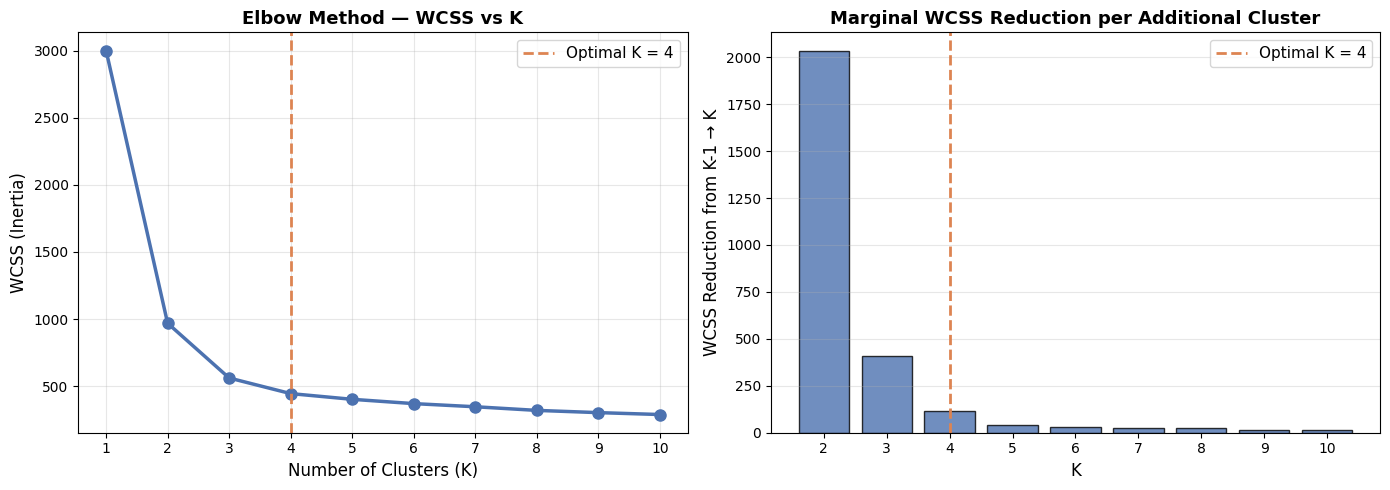

In [ ]:
# Plot the Elbow Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: WCSS curve
axes[0].plot(list(k_range), wcss, 'bo-', linewidth=2.5, markersize=8, color='#4C72B0')
axes[0].axvline(x=4, color='#DD8452', linestyle='--', linewidth=2, label='Optimal K = 4')
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('WCSS (Inertia)', fontsize=12)
axes[0].set_title('Elbow Method — WCSS vs K', fontsize=13, fontweight='bold')
axes[0].set_xticks(list(k_range))
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Right: WCSS drop (marginal gain) — helps spot elbow clearly
drops = [abs(wcss[i] - wcss[i+1]) for i in range(len(wcss)-1)]
axes[1].bar(range(2, 11), drops, color='#4C72B0', edgecolor='black', alpha=0.8)
axes[1].axvline(x=4, color='#DD8452', linestyle='--', linewidth=2, label='Optimal K = 4')
axes[1].set_xlabel('K', fontsize=12)
axes[1].set_ylabel('WCSS Reduction from K-1 → K', fontsize=12)
axes[1].set_title('Marginal WCSS Reduction per Additional Cluster', fontsize=13, fontweight='bold')
axes[1].set_xticks(range(2, 11))
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('elbow_plot.png', dpi=150, bbox_inches='tight')
plt.show()


### Optimal K Selection — Justification

**Chosen K = 4**

The elbow curve and the marginal-reduction bar chart both point clearly to **K = 4** as the optimal number of clusters:

| Transition | WCSS Drop | Interpretation |
|---|---|---|
| K=1 → K=2 | 2,031 | Massive — data is clearly not one group |
| K=2 → K=3 | 408 | Large — still meaningful structure |
| K=3 → K=4 | 116 | Moderate — still useful separation |
| K=4 → K=5 | 43 | **Sharp drop-off — diminishing returns begin** |
| K=5 → K=6 | 32 | Small |
| K=6+ | < 30 | Marginal |

The "elbow" — where the curve transitions from steep decline to a flatter gradient — occurs at **K = 4**. Beyond this point, adding more clusters produces only minor WCSS reductions while increasing model complexity and reducing interpretability. K = 4 also yields four meaningfully distinct customer segments that map well to real business archetypes (as interpreted in Task 3).


## Task 3 — K-Means Clustering (K = 4)

In [ ]:
# Fit K-Means with K = 4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print("Cluster assignment counts:")
print(df['cluster'].value_counts().sort_index())
print()
print(f"Total customers: {len(df)}")


Cluster assignment counts:
cluster
0    170
1     80
2    165
3     85
Name: count, dtype: int64

Total customers: 500


In [ ]:
# Print cluster centroids in original (unscaled) units for interpretability
feature_cols = [c for c in df.columns if c != 'cluster']
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=feature_cols
)
centroids.index.name = 'Cluster'
centroids.index = [f'Cluster {i}' for i in centroids.index]

print("Cluster Centroids (original scale):")
centroids.round(1)


Cluster Centroids (original scale):


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
Cluster 0,24.7,14847.4,14.3,559.0,9.1,2.1
Cluster 1,57.0,89814.1,2.5,5296.4,148.0,7.5
Cluster 2,40.4,43340.7,8.2,2021.7,35.2,4.4
Cluster 3,56.5,89036.2,2.6,5751.0,65.2,7.5


In [ ]:
# Cluster summary — mean of original features per cluster
cluster_summary = df.groupby('cluster')[feature_cols].mean().round(1)
cluster_summary.index = [f'Cluster {i}' for i in cluster_summary.index]
print("Cluster Means (original scale):")
cluster_summary


Cluster Means (original scale):


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
Cluster 0,24.7,14847.4,14.3,559.0,9.1,2.1
Cluster 1,57.0,89814.1,2.5,5296.4,148.0,7.5
Cluster 2,40.4,43340.7,8.2,2021.7,35.2,4.4
Cluster 3,56.5,89036.2,2.6,5751.0,65.2,7.5


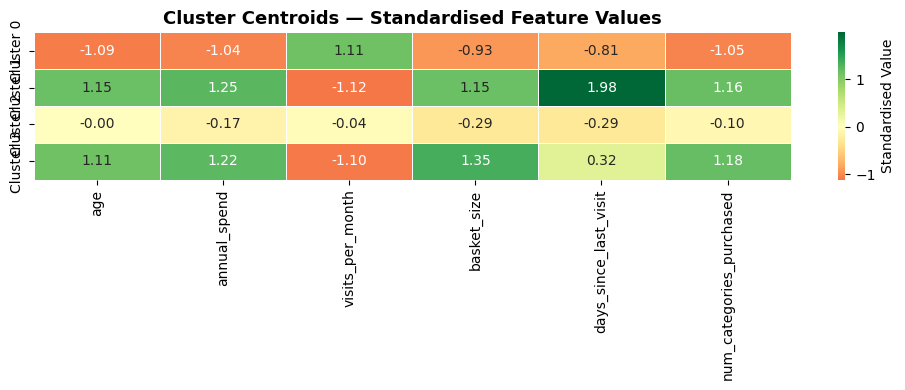

In [ ]:
# Visualise cluster profiles with a heatmap of scaled centroids
centroid_scaled = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=feature_cols,
    index=[f'Cluster {i}' for i in range(4)]
)

plt.figure(figsize=(10, 4))
sns.heatmap(centroid_scaled, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, cbar_kws={'label': 'Standardised Value'})
plt.title('Cluster Centroids — Standardised Feature Values', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('centroid_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


### Business Interpretation of Clusters

| Cluster | Age | Annual Spend | Visits/Month | Basket Size | Days Since Last Visit | Categories | Label |
|---|---|---|---|---|---|---|---|
| **0** | 25 | £14,847 | 14.3 | £559 | 9 | 2.1 | 🟢 Young Frequent Micro-Spenders |
| **1** | 57 | £89,814 | 2.5 | £5,296 | 148 | 7.5 | 🔴 Lapsed High-Value Seniors |
| **2** | 40 | £43,341 | 8.2 | £2,022 | 35 | 4.4 | 🔵 Mid-Life Balanced Shoppers |
| **3** | 57 | £89,036 | 2.6 | £5,751 | 65 | 7.5 | 🟡 Affluent Infrequent Seniors |

**Cluster 0 — Young Frequent Micro-Spenders (n ≈ 170)**  
Young customers (~25) who visit very frequently (14×/month) but spend little per trip (basket size £559) and buy across few categories. These are likely budget-conscious students or early-career shoppers. *Business action: upsell with bundle deals and loyalty rewards to grow basket size.*

**Cluster 1 — Lapsed High-Value Seniors (n ≈ 80)**  
Older customers (~57) with high annual spend (£89,814) and large baskets (£5,296) but very infrequent visits (2.5×/month) and long recency (148 days since last visit). These high-value customers are at churn risk. *Business action: targeted win-back campaigns, personalised re-engagement emails.*

**Cluster 2 — Mid-Life Balanced Shoppers (n ≈ 165)**  
Middle-aged customers (~40) with moderate spend (£43,341), moderate visit frequency (8×/month), and moderate basket sizes. The most "average" segment — a reliable core customer base. *Business action: maintain engagement with consistent promotions and loyalty programmes.*

**Cluster 3 — Affluent Infrequent Seniors (n ≈ 85)**  
Similar age and spend to Cluster 1 but with better recency (65 days vs 148). These are premium shoppers who visit less frequently but spend heavily per trip across many categories. *Business action: VIP experiences, premium product recommendations, and exclusive early-access offers.*


## Task 4 — Dimensionality Reduction with PCA

In [ ]:
# Apply PCA — reduce to 2 principal components
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Explained variance ratio
print("Explained Variance Ratio:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var:.4f}  ({var*100:.2f}%)")
print(f"  Total: {sum(pca.explained_variance_ratio_)*100:.2f}%")


Explained Variance Ratio:
  PC1: 0.8356  (83.56%)
  PC2: 0.0557  (5.57%)
  Total: 89.13%


In [ ]:
# Feature loadings — how much each original feature contributes to each PC
loadings = pd.DataFrame(
    pca.components_,
    columns=feature_cols,
    index=['PC1', 'PC2']
)
print("Feature Loadings (PCA Components):")
loadings.round(3)


Feature Loadings (PCA Components):


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.412,0.422,-0.410,0.412,0.379,0.414
PC2,-0.259,-0.033,0.208,-0.195,0.911,-0.140


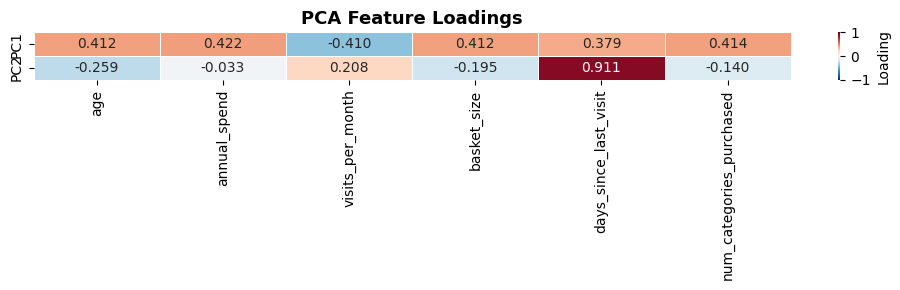

In [ ]:
# Visualise loadings as a heatmap
plt.figure(figsize=(10, 3))
sns.heatmap(loadings, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, linewidths=0.5, vmin=-1, vmax=1,
            cbar_kws={'label': 'Loading'})
plt.title('PCA Feature Loadings', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pca_loadings.png', dpi=150, bbox_inches='tight')
plt.show()


### Interpretation of PC1 and PC2

**PC1 — "Customer Value & Engagement" (83.6% variance explained)**

PC1 loads strongly and approximately equally on almost all features:

| Feature | Loading | Direction |
|---|---|---|
| `annual_spend` | +0.422 | Higher spend → higher PC1 |
| `num_categories_purchased` | +0.414 | More categories → higher PC1 |
| `age` | +0.412 | Older → higher PC1 |
| `basket_size` | +0.412 | Larger baskets → higher PC1 |
| `days_since_last_visit` | +0.379 | Less recent → higher PC1 |
| `visits_per_month` | −0.410 | More frequent → **lower** PC1 |

PC1 essentially captures the contrast between **high-value, infrequent, older, broad-category shoppers** (high PC1) and **young, frequent, low-spend, narrow-category shoppers** (low PC1). This single component alone explains **83.6%** of all variance — a remarkably strong summary axis.

**PC2 — "Recency vs Activity" (5.6% variance explained)**

PC2 is dominated by a single feature:

| Feature | Loading | Direction |
|---|---|---|
| `days_since_last_visit` | +0.911 | Primary driver |
| All others | < ±0.26 | Weak contributions |

PC2 primarily separates customers by **recency** — how long since they last visited — independent of their spend level. A customer can be high-value (high PC1) but either recently active (low PC2) or lapsed (high PC2). This is the distinction that separates Cluster 3 (affluent, recent) from Cluster 1 (affluent, lapsed) in the scatter plot.

Together, PC1 and PC2 capture **89.1%** of total variance, making the 2D projection a faithful representation of the original 6-dimensional data.


## Task 5 — Cluster Visualisation

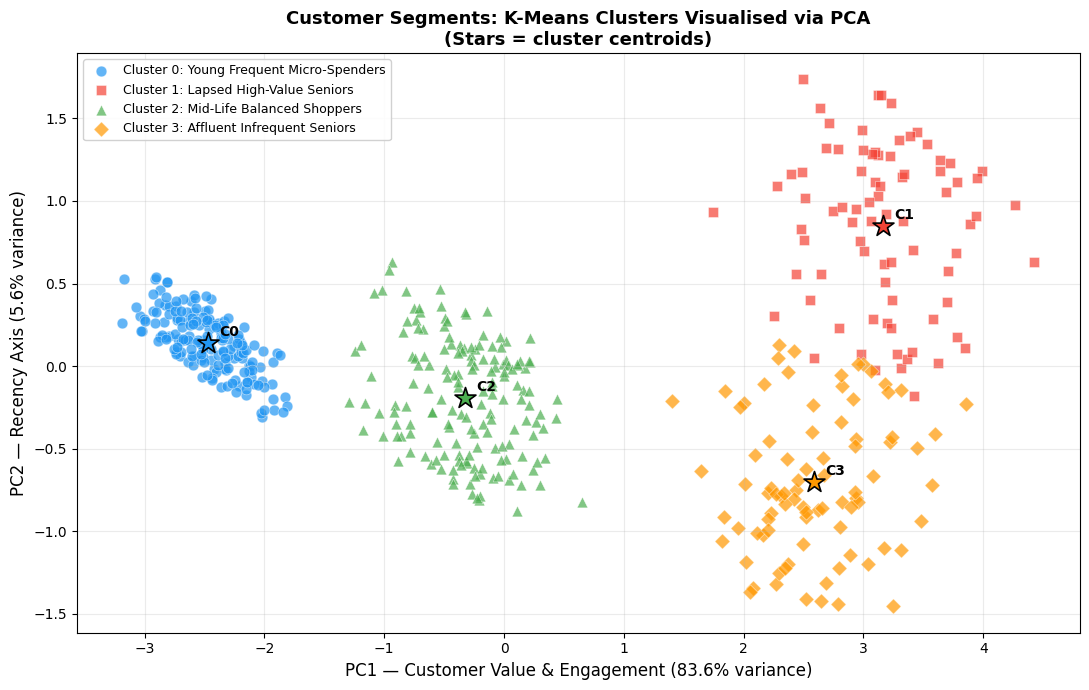

Plot saved. Total customers plotted: 500


In [ ]:
# Scatter plot: PC1 vs PC2 coloured by cluster
cluster_labels = {
    0: 'Cluster 0: Young Frequent Micro-Spenders',
    1: 'Cluster 1: Lapsed High-Value Seniors',
    2: 'Cluster 2: Mid-Life Balanced Shoppers',
    3: 'Cluster 3: Affluent Infrequent Seniors',
}
colors = ['#2196F3', '#F44336', '#4CAF50', '#FF9800']
markers = ['o', 's', '^', 'D']

fig, ax = plt.subplots(figsize=(11, 7))

for cluster_id in sorted(df['cluster'].unique()):
    mask = df['cluster'] == cluster_id
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=colors[cluster_id],
        marker=markers[cluster_id],
        label=cluster_labels[cluster_id],
        alpha=0.7, s=60, edgecolors='white', linewidths=0.4
    )

# Plot centroids
centroids_pca = pca.transform(kmeans.cluster_centers_)
for i, (cx, cy) in enumerate(centroids_pca):
    ax.scatter(cx, cy, c=colors[i], s=250, marker='*',
               edgecolors='black', linewidths=1.2, zorder=5)
    ax.annotate(f'C{i}', (cx, cy), textcoords='offset points',
                xytext=(8, 5), fontsize=10, fontweight='bold')

ax.set_xlabel('PC1 — Customer Value & Engagement (83.6% variance)', fontsize=12)
ax.set_ylabel('PC2 — Recency Axis (5.6% variance)', fontsize=12)
ax.set_title('Customer Segments: K-Means Clusters Visualised via PCA\n'
             '(Stars = cluster centroids)', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('cluster_pca_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Plot saved. Total customers plotted: {len(df)}")


### Visualisation Notes

The PCA scatter plot confirms the four clusters are **well-separated** in 2D space:

- **Cluster 0** (blue circles) — tightly grouped in the **bottom-left**: low PC1 (low value/older age) and low PC2 (recently active), consistent with young frequent low-spenders.
- **Cluster 2** (green triangles) — centre-left: moderate PC1, low-to-mid PC2 — the balanced mid-tier segment.
- **Cluster 3** (orange diamonds) — **top-right**: high PC1 (high value, older) and low-to-mid PC2 (reasonably recent) — affluent active seniors.
- **Cluster 1** (red squares) — **far right, high PC2**: high PC1 AND very high PC2 — these are the lapsed high-value customers who haven't visited in a long time.

The star markers show centroids, which sit at the geometric centre of each cluster, confirming K-Means has converged correctly. The clear visual separation validates that K = 4 was an appropriate choice.
